<a href="https://colab.research.google.com/github/anilpomar/Full-Stack-Gen-AI-BootCamp-KrishNaik-/blob/main/LLM_Fine_Tuning_Techniques_Non_Instruction%2CInstruction_And_Preference_Data_using_Huggingface.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Test Ok")

Test Ok


1. dataclass
2. enum class
3. pydantic class
4. typedict class
5. abstract class

Above Classes are used for Data Validation And Configuration

In [2]:
# ============================================================
# 1. Install required libraries
# ============================================================
# PyMuPDF: PDF text extraction
# datasets: Hugging Face dataset creation
# transformers/accelerate: model, tokenizer, Trainer
# peft: LoRA/QLoRA adapters
# bitsandbytes: 4-bit/8-bit quantized loading

!pip install -q -U pymupdf datasets transformers accelerate peft bitsandbytes sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.7 MB/s eta 0:00:00


In [3]:
#This Code Ignore all warnings that occured
import warnings
warnings.filterwarnings("ignore")

In [4]:
# ============================================================
# 2. Imports
# ============================================================

import os
import re
import gc
import math
import json
import random
import unicodedata
from dataclasses import dataclass, asdict
from typing import List, Dict, Any

import fitz  # PyMuPDF
import torch
from datasets import Dataset, DatasetDict

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    set_seed,
)

from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel,
)

In [5]:
from google.colab import userdata
WriteToken=userdata.get('HuggingFace_Write')

In [6]:
# ============================================================
# 3. Global configuration
# ============================================================
# Keep all important parameters in one place.
# This makes the notebook easier to debug, reproduce, and productionize.
# In Modular coding all these parameters will be placed in config or external confiuration

from dataclasses import dataclass, asdict

@dataclass
class Config:
    # Path of the pharma PDF file that will be used as the raw domain corpus.
    pdf_path: str = "/content/Metformin-Lipid-Therapy-Knowledge.pdf"

    # Base causal language model that we will fine-tune on pharma-domain text.
    #Any model can be used here
    model_name: str = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"

    # Directory where training checkpoints will be saved during fine-tuning.
    output_dir: str = "/content/pharma_tinyllama_lora_output"

    # Directory where the final trained LoRA adapter will be saved.
    adapter_dir: str = "/content/pharma_tinyllama_lora_adapter"

    # Directory where cleaned and processed training data will be saved.
    processed_data_dir: str = "/content/pharma_processed_data"

    # Minimum paragraph length required to keep a paragraph for training.
    min_chars_per_paragraph: int = 80

    # Number of tokens in each training block for causal language modeling.
    block_size: int = 512

    # Percentage of data used for validation instead of training.
    test_size: float = 0.15

    # Random seed used to make splitting and training more reproducible.
    seed: int = 42

    # LoRA rank; controls the size and capacity of the trainable adapter.
    lora_r: int = 16

    # LoRA scaling factor; controls the strength of the LoRA update.
    lora_alpha: int = 32

    # Dropout applied inside LoRA layers to reduce overfitting.
    lora_dropout: float = 0.05

    # Number of times the model will see the complete training dataset.
    num_train_epochs: float = 3.0

    # Number of training samples processed per GPU/device at one time.
    per_device_train_batch_size: int = 1

    # Number of validation samples processed per GPU/device at one time.
    per_device_eval_batch_size: int = 1

    # Number of small batches accumulated before one optimizer update.
    gradient_accumulation_steps: int = 8

    # Step size used by the optimizer to update trainable LoRA weights.
    learning_rate: float = 2e-4

    # Fraction of early training steps used to gradually increase learning rate.
    warmup_ratio: float = 0.03

    # Regularization value used to prevent weights from becoming too large.
    weight_decay: float = 0.01

    # Number of training steps after which logs will be printed.
    logging_steps=1
    logging_first_step=True

    # Number of training steps after which validation will be performed.
    eval_steps: int = 10

    # Number of training steps after which a checkpoint will be saved.
    save_steps: int = 25

    # Maximum number of checkpoints to keep; older checkpoints will be deleted.
    save_total_limit: int = 2

    # Maximum number of training steps; -1 means train using num_train_epochs.
    max_steps: int = -1

In [7]:
config = Config()

In [8]:
# ============================================================
# Hugging Face repo names
# ============================================================

HF_USERNAME = "AnilPomar14"

BASE_MODEL_NAME = config.model_name

# Stage 1: Non-instruction LoRA adapter
HF_REPO_NON_INSTRUCTION_ADAPTER = f"{HF_USERNAME}/pharma-tinyllama-non-instruction-lora-adapter"

# Stage 1 merged model
HF_REPO_NON_INSTRUCTION_MERGED = f"{HF_USERNAME}/pharma-tinyllama-non-instruction-merged"

# Stage 2: Instruction LoRA adapter
HF_REPO_INSTRUCTION_ADAPTER = f"{HF_USERNAME}/pharma-tinyllama-instruction-lora-adapter"

# Stage 2 merged model
HF_REPO_INSTRUCTION_MERGED = f"{HF_USERNAME}/pharma-tinyllama-instruction-merged"

# Stage 3: DPO preference LoRA adapter
HF_REPO_DPO_ADAPTER = f"{HF_USERNAME}/pharma-tinyllama-dpo-lora-adapter"

# Stage 3 final merged model
HF_REPO_DPO_MERGED = f"{HF_USERNAME}/pharma-tinyllama-dpo-merged"

print(HF_REPO_NON_INSTRUCTION_ADAPTER)
print(HF_REPO_INSTRUCTION_ADAPTER)
print(HF_REPO_DPO_ADAPTER)

AnilPomar14/pharma-tinyllama-non-instruction-lora-adapter
AnilPomar14/pharma-tinyllama-instruction-lora-adapter
AnilPomar14/pharma-tinyllama-dpo-lora-adapter


In [9]:
config
#print(json.dumps(asdict(config), indent=2))

Config(pdf_path='/content/Metformin-Lipid-Therapy-Knowledge.pdf', model_name='TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T', output_dir='/content/pharma_tinyllama_lora_output', adapter_dir='/content/pharma_tinyllama_lora_adapter', processed_data_dir='/content/pharma_processed_data', min_chars_per_paragraph=80, block_size=512, test_size=0.15, seed=42, lora_r=16, lora_alpha=32, lora_dropout=0.05, num_train_epochs=3.0, per_device_train_batch_size=1, per_device_eval_batch_size=1, gradient_accumulation_steps=8, learning_rate=0.0002, warmup_ratio=0.03, weight_decay=0.01, eval_steps=10, save_steps=25, save_total_limit=2, max_steps=-1)

In [10]:
Config

__main__.Config

In [11]:
Config.block_size


512

In [12]:
Config.output_dir

'/content/pharma_tinyllama_lora_output'

In [13]:
os.makedirs(config.output_dir, exist_ok=True)
os.makedirs(config.adapter_dir, exist_ok=True)
os.makedirs(config.processed_data_dir, exist_ok=True)

In [14]:
#Check whether Test Data PDF File is available

if not os.path.exists(config.pdf_path):
    print(f"PDF not found at: {config.pdf_path}")
else:
    print(f"PDF found: {config.pdf_path}")

PDF found: /content/Metformin-Lipid-Therapy-Knowledge.pdf


In [15]:
# # ============================================================
# #  Extract text from PDF
# # ============================================================
from typing import List, Dict, Any
import fitz  # PyMuPDF
def extract_pdf_pages(pdf_path: str) -> List[Dict[str, Any]]:
    # Extract page-level text from a PDF.
    pages = []
    with fitz.open(pdf_path) as doc:
        for page_index, page in enumerate(doc, start=1):
            text = page.get_text("text")
            text = text.strip() if text else ""
            if text:
                pages.append({
                    "page": page_index,
                    "text": text,
                    "char_count": len(text),
                })
    return pages

In [16]:
config.pdf_path

'/content/Metformin-Lipid-Therapy-Knowledge.pdf'

In [17]:
#Read PDF Extract pages from it.
pdf_pages=extract_pdf_pages(config.pdf_path)

print(f"Total pages with extracted text: {len(pdf_pages)}")
print("Page-level character counts:")
for item in pdf_pages:
    print(f"Page {item['page']}: {item['char_count']} characters")

Total pages with extracted text: 6
Page-level character counts:
Page 1: 2244 characters
Page 2: 2889 characters
Page 3: 2636 characters
Page 4: 2416 characters
Page 5: 2613 characters
Page 6: 2761 characters


In [18]:
#Check Data from loaded Pages object

print(pdf_pages[0]["text"])


Metformin is one of the most widely prescribed oral antihyperglycemic agents.​
 Its primary mechanism of action involves the activation of AMP-activated protein kinase 
(AMPK), a central metabolic regulator that promotes glucose uptake and fatty acid oxidation 
while inhibiting hepatic gluconeogenesis.​
 Beyond its glycemic control, Metformin has been shown to improve cardiovascular outcomes 
and display anti-inflammatory properties.​
 Recent studies also suggest potential anticancer effects through inhibition of the mTOR 
signaling pathway and suppression of tumor angiogenesis. 
 
Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe results in 
significant reductions in low-density lipoprotein cholesterol (LDL-C) levels compared to 
monotherapy.​
 Ezetimibe acts by inhibiting the Niemann–Pick C1-like 1 (NPC1L1) transporter in the intestinal 
wall, reducing cholesterol absorption, while Atorvastatin inhibits hepatic HMG-CoA reductase, 
suppressing endogenous cho

**Text Cleaning**

**Now we need to Clean the Data to avoid anomalies**

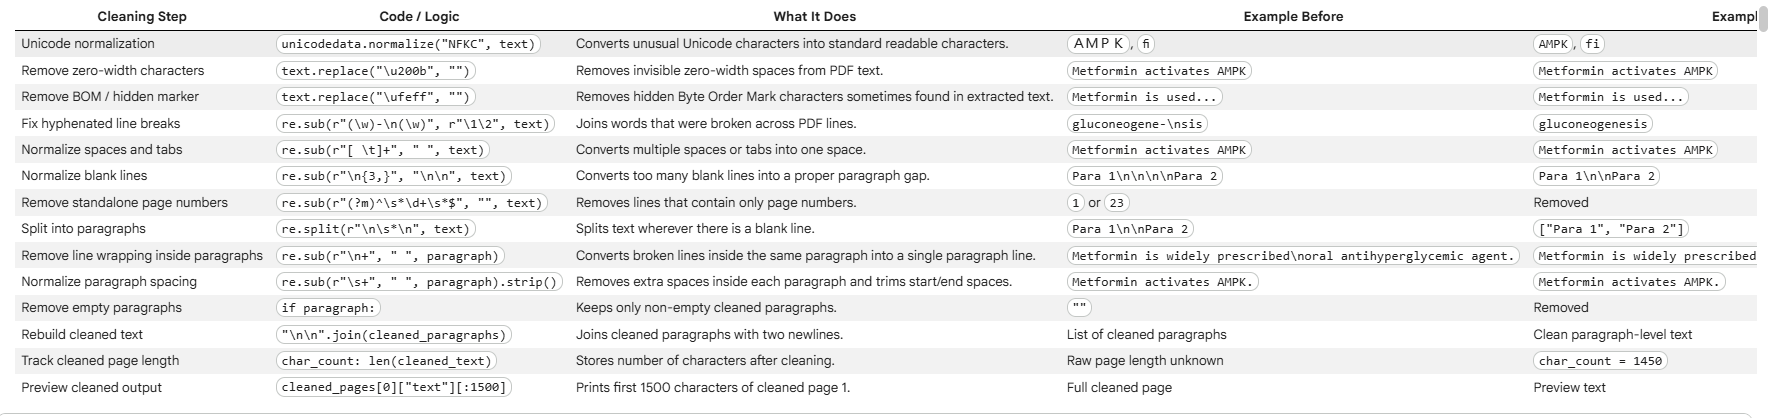


In [19]:
#Text Cleaning

import re
import unicodedata

def clean_pdf_text(text: str) -> str:
    # Standardize Unicode text so visually similar characters are treated consistently.
    # Example: "ＡＭＰＫ" becomes "AMPK" and "ﬁ" becomes "fi".
    text = unicodedata.normalize("NFKC", text)


    # Remove invisible characters that may appear during PDF text extraction.
    # It is very important to remove to avoid confusion to Tokenizer.
    text = text.replace("\u200b", "").replace("\ufeff", "")

    # Join words broken by line hyphenation, e.g., "gluconeogene-\nsis" -> "gluconeogenesis".
    text = re.sub(r"(\w)-\n(\w)", r"\1\2", text)

    # Replace multiple spaces/tabs with a single space.
    text = re.sub(r"[ \t]+", " ", text)

    # Convert three or more newlines into a standard paragraph break.
    text = re.sub(r"\n{3,}", "\n\n", text)

    # Remove lines that contain only page numbers.
    text = re.sub(r"(?m)^\s*\d+\s*$", "", text)

    # Split text into paragraphs, clean each paragraph, and remove empty ones.
    paragraphs = []
    for paragraph in re.split(r"\n\s*\n", text):
        paragraph = re.sub(r"\n+", " ", paragraph)
        paragraph = re.sub(r"\s+", " ", paragraph).strip()

        if paragraph:
            paragraphs.append(paragraph)

    # Join cleaned paragraphs with one blank line between them.
    return "\n\n".join(paragraphs)

In [20]:
cleaned_pages = []

In [21]:
for page in pdf_pages:
    cleaned_text = clean_pdf_text(page["text"])
    cleaned_pages.append({
        "page": page["page"],
        "text": cleaned_text,
        "char_count": len(cleaned_text),
    })

    print("Total cleaned pages:", len(cleaned_pages))

Total cleaned pages: 1
Total cleaned pages: 2
Total cleaned pages: 3
Total cleaned pages: 4
Total cleaned pages: 5
Total cleaned pages: 6


In [22]:
# Check First Page from Cleaned Pages
print(cleaned_pages[0]["text"])

Metformin is one of the most widely prescribed oral antihyperglycemic agents. Its primary mechanism of action involves the activation of AMP-activated protein kinase (AMPK), a central metabolic regulator that promotes glucose uptake and fatty acid oxidation while inhibiting hepatic gluconeogenesis. Beyond its glycemic control, Metformin has been shown to improve cardiovascular outcomes and display anti-inflammatory properties. Recent studies also suggest potential anticancer effects through inhibition of the mTOR signaling pathway and suppression of tumor angiogenesis.

Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe results in significant reductions in low-density lipoprotein cholesterol (LDL-C) levels compared to monotherapy. Ezetimibe acts by inhibiting the Niemann–Pick C1-like 1 (NPC1L1) transporter in the intestinal wall, reducing cholesterol absorption, while Atorvastatin inhibits hepatic HMG-CoA reductase, suppressing endogenous cholesterol synthesis

**To Perform Non-Instruction Fine tuning we require Text Column which we need to add to cleaned_pages collection**

In [23]:
# ============================================================
# Split cleaned pages into paragraphs
# ============================================================
# This step converts cleaned page-level text into paragraph-level records.

def split_into_paragraph_records(cleaned_pages, min_chars=80):
    paragraph_records = []

    for page in cleaned_pages:
        # Split page text into paragraphs using blank lines.
        paragraphs = page["text"].split("\n\n")

        for paragraph_index, paragraph in enumerate(paragraphs, start=1):
            # Remove extra spaces from the beginning and end.
            paragraph = paragraph.strip()

            # Skip very short paragraphs because they are usually headings, page numbers, or noise.
            if len(paragraph) < min_chars:
                continue

            # Store each useful paragraph with basic metadata.
            paragraph_records.append({
                "text": paragraph,
                "source_page": page["page"],
                "paragraph_id": paragraph_index,
                "char_count": len(paragraph),
            })

    return paragraph_records

In [24]:
paragraph_records = split_into_paragraph_records(cleaned_pages)
print(len(paragraph_records))

9


**Checking the data as this will be final data set used for Training**

In [25]:
for record in paragraph_records[:4]:
    print("=" * 60)
    print(f"Page: {record['source_page']} | Paragraph: {record['paragraph_id']} | Characters: {record['char_count']}")
    print(record["text"])

Page: 1 | Paragraph: 1 | Characters: 575
Metformin is one of the most widely prescribed oral antihyperglycemic agents. Its primary mechanism of action involves the activation of AMP-activated protein kinase (AMPK), a central metabolic regulator that promotes glucose uptake and fatty acid oxidation while inhibiting hepatic gluconeogenesis. Beyond its glycemic control, Metformin has been shown to improve cardiovascular outcomes and display anti-inflammatory properties. Recent studies also suggest potential anticancer effects through inhibition of the mTOR signaling pathway and suppression of tumor angiogenesis.
Page: 1 | Paragraph: 2 | Characters: 598
Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe results in significant reductions in low-density lipoprotein cholesterol (LDL-C) levels compared to monotherapy. Ezetimibe acts by inhibiting the Niemann–Pick C1-like 1 (NPC1L1) transporter in the intestinal wall, reducing cholesterol absorption, while Atorvastatin

In [26]:
# ============================================================
# Save extracted and cleaned corpus for auditability
# ============================================================
# In real projects, always save intermediate datasets.
# This helps with reproducibility, debugging, and compliance review.

raw_pages_path = os.path.join(config.processed_data_dir, "pdf_pages_raw.jsonl")
paragraphs_path = os.path.join(config.processed_data_dir, "pharma_paragraph_process.jsonl")

with open(raw_pages_path, "w", encoding="utf-8") as f:
    for item in pdf_pages:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

with open(paragraphs_path, "w", encoding="utf-8") as f:
    for item in paragraph_records:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"Saved raw pages to: {raw_pages_path}")
print(f"Saved cleaned paragraph corpus to: {paragraphs_path}")

Saved raw pages to: /content/pharma_processed_data/pdf_pages_raw.jsonl
Saved cleaned paragraph corpus to: /content/pharma_processed_data/pharma_paragraph_process.jsonl


**The Data which is cleaned and processed is not HuggingFace Compatible data**

*Now need to Convert to Huggingface format*

In [27]:
# ============================================================
# Create Hugging Face Dataset
# ============================================================
from datasets import Dataset
if len(paragraph_records) < 2:
    raise ValueError(
        "The extracted corpus is too small. Please provide a larger pharma PDF or lower min_chars_per_paragraph."
    )
text_dataset = Dataset.from_list(paragraph_records)

In [28]:
#Now Dataset is Huggingface Format Compatible
print(text_dataset)

Dataset({
    features: ['text', 'source_page', 'paragraph_id', 'char_count'],
    num_rows: 9
})


In [29]:
print(text_dataset[0])

{'text': 'Metformin is one of the most widely prescribed oral antihyperglycemic agents. Its primary mechanism of action involves the activation of AMP-activated protein kinase (AMPK), a central metabolic regulator that promotes glucose uptake and fatty acid oxidation while inhibiting hepatic gluconeogenesis. Beyond its glycemic control, Metformin has been shown to improve cardiovascular outcomes and display anti-inflammatory properties. Recent studies also suggest potential anticancer effects through inhibition of the mTOR signaling pathway and suppression of tumor angiogenesis.', 'source_page': 1, 'paragraph_id': 1, 'char_count': 575}


**We have Completed Data Injection Process**

***Now Lets Split data for Training And Validation***

In [30]:
# ============================================================
# Train/eval split
# ============================================================
# Even for small demos, keep an evaluation set.
# This gives us validation loss and perplexity.
# Here 15% of data will be allocated to Validation and 85% for Traning.
split_dataset = text_dataset.train_test_split(test_size=config.test_size, seed=config.seed)

from datasets import DatasetDict

dataset = DatasetDict({
    "train": split_dataset["train"],
    "validation": split_dataset["test"],
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'source_page', 'paragraph_id', 'char_count'],
        num_rows: 7
    })
    validation: Dataset({
        features: ['text', 'source_page', 'paragraph_id', 'char_count'],
        num_rows: 2
    })
})


**Load tokenizer**

The tokenizer converts text into token IDs.

For causal language modeling, the model learns:

```text
Given previous tokens, predict the next token.
```

This is why we call it **non-instruction causal LM fine-tuning**.

## What Does `512` Mean in Text Packing?

In this notebook, `512` means the **sequence length** or **block size** used for causal language model training.

It is **not the embedding size**.

It simply means:

> Each training example will contain 512 tokens.

---

## Example

Suppose the tokenizer converts our pharma text into 1,300 tokens:

```text
[token_1, token_2, token_3, ..., token_1300]?

if we set:

block_size = 512

then the tokens are split like this:

Block 1 = token 1 to token 512
Block 2 = token 513 to token 1024
Remaining tokens = token 1025 to token 1300

Is 512 Padding?

Not exactly.

512 is the target length of each training block.

If we use text packing, we try to fill each block with real tokens, so padding is reduced.

Without packing:

Paragraph 1 = 100 tokens + 412 padding tokens
Paragraph 2 = 200 tokens + 312 padding tokens

With packing:

Block 1 = 512 real tokens
Block 2 = 512 real tokens

So 512 is the fixed token length used to make training efficient.

Is 512 Embedding Size?

No.

Embedding size means the hidden vector dimension of the model.

For example, a model may convert each token into a vector like:

token → 2048-dimensional vector

That 2048 is embedding/hidden size.

But 512 here means:

How many tokens we give to the model at one time

**Pad token**
When are abmormal words in sentence passed to Model, it takes maxium words sentence and set 0 to other sentence which has less words than max words sentence.


```markdown
Ex:
***Before Padding***
I love India
I Love India Anil
I love India Anil Pomar

**After Applying padding **

I love India  0    0
I Love India Anil  0
I love India Anil Pomar
```

In [31]:
# ============================================================
# Load tokenizer
#    (which Converts Text into Tokens)
#    Here we load Model Into VRAM If want to load into Disk we need to use Snapshot
# ============================================================

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(config.model_name, use_fast=True)

# Some Llama-style models do not define a pad token.
# For causal LM fine-tuning, using EOS as PAD is a common practical choice.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

In [32]:
tokenizer.eos_token

'</s>'

In [33]:
print(f"Tokenizer loaded: {config.model_name}")
print(f"Vocab size: {len(tokenizer)}")
print(f"Pad token: {tokenizer.pad_token} | Pad token id: {tokenizer.pad_token_id}")
print(f"EOS token: {tokenizer.eos_token} | EOS token id: {tokenizer.eos_token_id}")

Tokenizer loaded: TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T
Vocab size: 32000
Pad token: </s> | Pad token id: 2
EOS token: </s> | EOS token id: 2


In [34]:
# ============================================================
# Tokenization and text packing
# ============================================================
def tokenize_function(examples):
    # Tokenize text without padding. Padding is handled dynamically by the collator.
    return tokenizer(examples["text"])

In [35]:
tokenized_datasets = dataset.map(
    tokenize_function,
    remove_columns=dataset["train"].column_names,
    desc="Tokenizing text corpus",
)

Tokenizing text corpus:   0%|          | 0/7 [00:00<?, ? examples/s]

Tokenizing text corpus:   0%|          | 0/2 [00:00<?, ? examples/s]

| Parameter                                       | Meaning                                                                                                                               |
| ----------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------- |
| `tokenize_function`                             | This function converts each text example into token IDs.                                                                              |
| `batched=True`                                  | The function processes multiple rows at once instead of one row at a time. This makes tokenization faster.                            |
| `remove_columns=datasets["train"].column_names` | After tokenization, the original dataset columns are removed. Only tokenized columns such as `input_ids` and `attention_mask` remain. |
| `desc="Tokenizing text corpus"`                 | This message is shown in the progress bar so we can understand that tokenization is currently running.                                |


In [36]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 7
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 2
    })
})

In [37]:
tokenized_datasets['train']['input_ids'][0]

[1,
 1963,
 22824,
 28460,
 26101,
 3630,
 448,
 9305,
 29871,
 29945,
 9305,
 29871,
 29945,
 448,
 319,
 29902,
 297,
 360,
 11124,
 8565,
 22205,
 322,
 1963,
 22824,
 346,
 329,
 936,
 390,
 29987,
 29928,
 29936,
 1963,
 22824,
 29899,
 7247,
 1034,
 13364,
 6081,
 363,
 2888,
 2691,
 29899,
 29873,
 27964,
 322,
 390,
 10051,
 7639,
 362,
 29889,
 7519,
 29883,
 1288,
 2793,
 871,
 29936,
 451,
 16083,
 9848,
 29889,
 17157,
 29769,
 3012,
 928,
 616,
 21082,
 338,
 10231,
 368,
 1304,
 297,
 1374,
 22824,
 346,
 329,
 936,
 5925,
 304,
 27599,
 20853,
 1199,
 29892,
 1301,
 924,
 290,
 1199,
 29892,
 3279,
 290,
 1199,
 29892,
 17135,
 17292,
 327,
 7384,
 29892,
 22233,
 9562,
 29892,
 322,
 24899,
 936,
 20035,
 29889,
 512,
 3646,
 29769,
 29892,
 4933,
 6509,
 4733,
 508,
 7536,
 277,
 675,
 2531,
 267,
 470,
 3279,
 1144,
 393,
 1122,
 1708,
 3269,
 284,
 16178,
 297,
 17135,
 4768,
 3002,
 29889,
 4525,
 27303,
 526,
 9324,
 6419,
 746,
 23387,
 411,
 17986,
 8845,
 29892,

In [38]:
 # Join all token IDs from multiple examples into one long list.

def create_training_blocks(tokenized_examples):
    all_input_ids = []
    all_attention_masks = []

    for input_ids in tokenized_examples["input_ids"]:
        all_input_ids.extend(input_ids)

    for attention_mask in tokenized_examples["attention_mask"]:
        all_attention_masks.extend(attention_mask)

    # Calculate how many complete blocks we can create.
    total_tokens = len(all_input_ids)
    usable_tokens = (total_tokens // config.block_size) * config.block_size

    # If we do not have enough tokens to create even one block, return empty data.
    if usable_tokens == 0:
        return {
            "input_ids": [],
            "attention_mask": [],
            "labels": [],
        }

    # Keep only tokens that can fit into complete fixed-size blocks.
    all_input_ids = all_input_ids[:usable_tokens]
    all_attention_masks = all_attention_masks[:usable_tokens]

    # Split the long token list into fixed-size training blocks.
    input_id_blocks = []
    attention_mask_blocks = []

    for start_index in range(0, usable_tokens, config.block_size):
        end_index = start_index + config.block_size

        input_id_blocks.append(all_input_ids[start_index:end_index])
        attention_mask_blocks.append(all_attention_masks[start_index:end_index])

    # For causal language modeling, labels are the same as input IDs.
    # The model uses these labels to learn next-token prediction.
    labels = input_id_blocks.copy()

    return {
        "input_ids": input_id_blocks,
        "attention_mask": attention_mask_blocks,
        "labels": labels,
    }

In [39]:
final_dataset = tokenized_datasets.map(
    create_training_blocks,
    batched=True,
    desc=f"Creating fixed-size training blocks of {config.block_size} tokens",
)

Creating fixed-size training blocks of 512 tokens:   0%|          | 0/7 [00:00<?, ? examples/s]

Creating fixed-size training blocks of 512 tokens:   0%|          | 0/2 [00:00<?, ? examples/s]

## What Does This Function Do?

This function converts tokenized text into **fixed-size training blocks**.

First, it joins all token IDs into one long sequence.  
Then, it cuts that long sequence into equal blocks of `config.block_size` tokens.

For causal language modeling, the labels are copied from `input_ids` because the model learns to predict the next token.

---

## Example

Suppose we have these tokenized inputs:

```text
Input token lists:

[10, 20, 30]
[40, 50]
[60, 70, 80, 90]

After joining all token lists together:

[10, 20, 30, 40, 50, 60, 70, 80, 90]

If:

block_size = 4

Then the final training blocks become:

Block 1 = [10, 20, 30, 40]
Block 2 = [50, 60, 70, 80]

The remaining token is:

[90]

This token is dropped because it cannot form a complete block of 4 tokens.

Simple Summary

This step prepares the final causal language modeling dataset by converting many small tokenized examples into equal-length token blocks.

In [40]:
sample = final_dataset["train"][0]

In [41]:
print("Keys:", sample.keys())
print("input_ids length:", len(sample["input_ids"]))
print("labels length:", len(sample["labels"]))
print("Decoded sample preview:\n")
print(tokenizer.decode(sample["input_ids"][:250]))

Keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
input_ids length: 512
labels length: 512
Decoded sample preview:

<s> Pharma Domain Training Data - Page 5 Page 5 - AI in Drug Discovery and Pharmaceutical R&D; Pharma-domain corpus extension for custom fine-tuning and RAG experimentation. Educational content only; not medical advice. Target identification Artificial intelligence is increasingly used in pharmaceutical research to analyze genomics, transcriptomics, proteomics, disease phenotypes, chemical libraries, and clinical datasets. In target identification, machine learning models can prioritize genes or proteins that may play causal roles in disease biology. These predictions are strengthened when integrated with experimental validation, pathway analysis, human genetics, and disease-relevant biomarkers. Molecular screening In early discovery, deep learning can support virtual screening by predicting protein-ligand binding affinity, molecular properties, toxicity signals,

## Load Model for QLoRA Training

In this step, we load the base model for fine-tuning.

If GPU is available, we load the model in **4-bit mode**.

This helps because:

- It uses less GPU memory
- It allows us to fine-tune larger models on limited hardware
- It is useful for Colab or small GPU environments
- It works well with LoRA/QLoRA fine-tuning

If GPU is not available, the model will load normally on CPU, but training will be much slower.

In [42]:
# ============================================================
# Load base model
# ============================================================
import torch
use_cuda = torch.cuda.is_available()
print("CUDA available:", use_cuda)
if use_cuda:
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [43]:
# Clear memory before loading the model.
import gc
gc.collect()
if use_cuda:
    torch.cuda.empty_cache()

**BitsAndBytesConfig**
is a configuration class from HuggingFace Transformers that lets you load large models in lower precision (quantized format) to dramatically reduce memory usage — making it possible to run huge LLMs on consumer GPUs

***The Core Problem It Solves***
Loading a model normally uses 32-bit floats (FP32) per weight. A 7B parameter model in FP32 needs:

7,000,000,000 params × 4 bytes = 28 GB of GPU memory ❌

Most consumer GPUs (RTX 3060, 4070, etc.) only have 8-12 GB. You can't fit it.
BitsAndBytesConfig lets you load the same model in 4-bit or 8-bit:

7,000,000,000 params × 0.5 bytes (4-bit) = 3.5 GB ✅

Now it fits on a small GPU.

**prepare_model_for_kbit_training**
It is a function from the PEFT library that prepares a quantized model (4-bit or 8-bit) for fine-tuning. Without it, training a quantized model would either crash or produce poor results.

***Why It's Needed***
When you load a model with BitsAndBytesConfig, the weights are frozen in low precision (4-bit/8-bit). You can't train them directly because:
Quantized model (4-bit)
        ↓
Weights are integers, not floats
        ↓
Gradients can't flow through integer math
        ↓
Training crashes or produces garbage

prepare_model_for_kbit_training fixes this by preparing the model properly for gradient computation.


In [44]:
from transformers import AutoModelForCausalLM

if use_cuda:
    from transformers import BitsAndBytesConfig
    from peft import prepare_model_for_kbit_training

    # Configure 4-bit quantization to reduce GPU memory usage.
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    # Load the base model in 4-bit mode on available GPU devices.
    base_model = AutoModelForCausalLM.from_pretrained(
        config.model_name,
        quantization_config=quantization_config,
        device_map="auto",
        trust_remote_code=True,
    )

    # Prepare the quantized model for stable LoRA/QLoRA training.
    base_model = prepare_model_for_kbit_training(base_model)

else:
    # Load the base model normally when GPU is not available.
    base_model = AutoModelForCausalLM.from_pretrained(
        config.model_name,
        torch_dtype=torch.float32,
        trust_remote_code=True,
    )

# Disable cache during training to reduce memory usage and avoid training warnings.
base_model.config.use_cache = False

print("Base model loaded successfully.")

model.safetensors:   0%|          | 0.00/4.40G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

Base model loaded successfully.


In [45]:
# ============================================================
# Apply LoRA (Low Rank Adaption) adapters
# ============================================================
# LoRA trains a small number of adapter parameters instead of updating all base model weights.
# This is cheaper than full fine-tuning and is widely used in real projects.
from peft import LoraConfig
from peft import TaskType

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=config.lora_r,
    lora_alpha=config.lora_alpha,
    lora_dropout=config.lora_dropout,
    bias="none",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)


**Why need of LoRA adapter and Its Usuage?**

 Applies the LoRA configuration (defined by lora_config) to your base_model. Instead of directly modifying all the weights of the base_model during fine-tuning (which would be computationally expensive and require a lot of memory), get_peft_model creates a new model that:

Keeps most of the base_model's weights frozen.
Introduces small, trainable adapter layers (LoRA adapters) into specific parts of the base_model (as specified in your lora_config, e.g., q_proj, k_proj, v_proj).
This approach significantly reduces the number of parameters that need to be trained, making fine-tuning much faster and more memory-efficient, while still achieving performance comparable to full fine-tuning.

In [46]:
from peft import get_peft_model
model = get_peft_model(base_model, lora_config)

In [47]:
model.print_trainable_parameters()

trainable params: 12,615,680 || all params: 1,112,664,064 || trainable%: 1.1338


As per above Output just fine tuning of
1.1338 percent of params (or) weights is enough.

In [48]:
# ============================================================
# Data collator
# ============================================================
from transformers import DataCollatorForLanguageModeling
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

## Why Do We Need `DataCollatorForLanguageModeling`?

After tokenization and text packing, our dataset contains token IDs in a training-ready structure.

However, the `Trainer` still needs a component that can take multiple examples from the dataset and convert them into a proper batch during training.

That component is called a **data collator**.

```python
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)
What Does the Data Collator Do?

The data collator prepares mini-batches for the model.

It handles things like:

Collecting multiple training examples together
Padding sequences if required
Converting examples into tensors
Preparing labels for language modeling
Example

Suppose our packed dataset has training examples like this:

Example 1 = 512 tokens
Example 2 = 512 tokens
Example 3 = 512 tokens

During training, the Trainer may take two examples at a time:

Batch = Example 1 + Example 2

The data collator converts them into tensors like:

input_ids shape      = [2, 512]
attention_mask shape = [2, 512]
labels shape         = [2, 512]

This is the format the model expects during training.

Why mlm=False?

mlm means Masked Language Modeling.

Masked Language Modeling is used for BERT-style models.

Example:

Metformin is used for [MASK].

The model predicts the masked word:

diabetes

But we are using TinyLlama, which is a causal language model.

Causal language models learn by predicting the next token from left to right.

Example:

Metformin → is
Metformin is → used
Metformin is used → for
Metformin is used for → diabetes

So we set:

mlm=False

This tells Hugging Face:

Do not use BERT-style masked language modeling. Use causal language modeling instead.

Why Is This Needed Even After Tokenization and Packing?

Tokenization converts text into token IDs.

Text packing groups token IDs into fixed-size blocks.

But the data collator prepares those blocks into actual training batches.

So the flow is:

Raw pharma text
   ↓
Tokenization
   ↓
Token IDs
   ↓
Text packing
   ↓
Fixed-size training blocks
   ↓
Data collator
   ↓
Mini-batches for Trainer
   ↓
Model training

In [49]:
# ============================================================
# Training arguments
# ============================================================
# These settings are designed for a small classroom/demo run.
# For larger corpora, increase dataset size, epochs, and evaluation frequency carefully.

from transformers import TrainingArguments

In [50]:
training_kwargs = dict(
    output_dir=config.output_dir,
    num_train_epochs=config.num_train_epochs,
    max_steps=config.max_steps,
    per_device_train_batch_size=config.per_device_train_batch_size,
    per_device_eval_batch_size=config.per_device_eval_batch_size,
    gradient_accumulation_steps=config.gradient_accumulation_steps,
    learning_rate=config.learning_rate,
    warmup_steps=5,
    weight_decay=config.weight_decay,

    # Log training loss at every step for small demo datasets.
    logging_steps=1,
    logging_first_step=True,

    eval_steps=config.eval_steps,
    save_steps=config.save_steps,
    save_total_limit=config.save_total_limit,
    fp16=use_cuda,
    bf16=False,
    report_to="none",
    remove_unused_columns=False,
)

In [51]:
from transformers import TrainingArguments
training_args = TrainingArguments(**training_kwargs)

In [52]:
# ============================================================
#  Build Trainer
# ============================================================
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=final_dataset["train"],
    eval_dataset=final_dataset["validation"],
    data_collator=data_collator,
)
print("Trainer is ready.")

Trainer is ready.


In [53]:
# ============================================================
# Start training
# ============================================================
train_result = trainer.train()
print("Training completed.")

Step,Training Loss
1,2.148971
2,2.148971
3,2.124403


Training completed.


In [54]:
for log in trainer.state.log_history:
    print(log)

{'loss': 2.14897084236145, 'grad_norm': 0.651655375957489, 'learning_rate': 0.0, 'epoch': 1.0, 'step': 1}
{'loss': 2.1489710807800293, 'grad_norm': 0.6577324867248535, 'learning_rate': 4e-05, 'epoch': 2.0, 'step': 2}
{'loss': 2.1244025230407715, 'grad_norm': 0.6357439160346985, 'learning_rate': 8e-05, 'epoch': 3.0, 'step': 3}
{'train_runtime': 20.5902, 'train_samples_per_second': 0.874, 'train_steps_per_second': 0.146, 'total_flos': 57901993426944.0, 'train_loss': 2.1407814820607505, 'epoch': 3.0, 'step': 3}


In [55]:
# ============================================================
# 19. Save adapter and tokenizer
# ============================================================
trainer.model.save_pretrained(config.adapter_dir)
tokenizer.save_pretrained(config.adapter_dir)

('/content/pharma_tinyllama_lora_adapter/tokenizer_config.json',
 '/content/pharma_tinyllama_lora_adapter/tokenizer.json')

In [56]:
print(f"LoRA adapter saved to: {config.adapter_dir}")
print("Saved files:")
print(os.listdir(config.adapter_dir))

LoRA adapter saved to: /content/pharma_tinyllama_lora_adapter
Saved files:
['adapter_model.safetensors', 'tokenizer_config.json', 'adapter_config.json', 'README.md', 'tokenizer.json']


In [57]:
import os

# ============================================================
# Push Stage 1 non-instruction LoRA adapter to Hugging Face
# ============================================================

trainer.model.push_to_hub(
    HF_REPO_NON_INSTRUCTION_ADAPTER,
    private=True,
    token=WriteToken
)


print("Stage 1 non-instruction LoRA adapter pushed to:")
print(HF_REPO_NON_INSTRUCTION_ADAPTER)

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 34.5kB / 50.5MB            

Stage 1 non-instruction LoRA adapter pushed to:
AnilPomar14/pharma-tinyllama-non-instruction-lora-adapter


In [58]:
# ============================================================
# Reload base model + LoRA adapter correctly
# ============================================================
# Clean old objects to free memory.

del trainer

try:
    del model
    del base_model
except NameError:
    pass

gc.collect()

if use_cuda:
    torch.cuda.empty_cache()

**Inference Model Now**

In [59]:
from transformers import AutoTokenizer
inference_tokenizer = AutoTokenizer.from_pretrained(config.adapter_dir, use_fast=True)

if inference_tokenizer.pad_token is None:
    inference_tokenizer.pad_token = inference_tokenizer.eos_token

In [60]:
if use_cuda:
    inference_base_model = AutoModelForCausalLM.from_pretrained(
        config.model_name,
        quantization_config=BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
        ),
        device_map="auto",
        trust_remote_code=True,
    )
else:
    inference_base_model = AutoModelForCausalLM.from_pretrained(
        config.model_name,
        torch_dtype=torch.float32,
        trust_remote_code=True,
    )

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [61]:
from peft import PeftModel
inference_model = PeftModel.from_pretrained(inference_base_model, config.adapter_dir)

In [62]:
inference_model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [63]:
print("Base model + LoRA adapter loaded successfully for inference.")

Base model + LoRA adapter loaded successfully for inference.


In [64]:
# ============================================================
# Inference helper
# ============================================================
# Since this is non-instruction fine-tuning, prompts should look like text continuations,
# not chat-style questions.

def generate_completion(prompt: str, max_new_tokens: int = 120) -> str:
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Convert prompt text into token IDs.
    inputs = inference_tokenizer(prompt, return_tensors="pt").to(device)

    # Generate text without calculating gradients because we are doing inference, not training.
    with torch.no_grad():
        outputs = inference_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=inference_tokenizer.eos_token_id,
        )

    # Convert generated token IDs back into readable text.
    return inference_tokenizer.decode(outputs[0], skip_special_tokens=True)

In [65]:
# ============================================================
# Test text continuation
# ============================================================
# These prompts are continuation-style prompts.
# In Notebook 2, we will create instruction prompts for Q&A.

prompts = [
    "Metformin is one of the most widely prescribed oral antihyperglycemic agents",
    "Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe",
    "Artificial intelligence is transforming pharmaceutical research by accelerating",
]

In [66]:
# ============================================================
# Test text continuation
# ============================================================

for prompt in prompts:
    print("=" * 100)
    print("PROMPT:")
    print(prompt)
    print("\nMODEL CONTINUATION:")
    print(generate_completion(prompt, max_new_tokens=120))
    print()

PROMPT:
Metformin is one of the most widely prescribed oral antihyperglycemic agents

MODEL CONTINUATION:


[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Metformin is one of the most widely prescribed oral antihyperglycemic agents in the world. It is a sulfonylurea class drug, which has been used to treat type 2 diabetes for over 30 years. However, despite its proven efficacy and safety, the mechanism by which it works remains unknown. A recent study from the National Institutes of Health (NIH) reveals that Metformin can directly affect the cellular processes that regulate the production of insulin. This finding could lead to the development of new drugs targeting these processes.
The NIH study was part of the Metabolomics

PROMPT:
Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe

MODEL CONTINUATION:


[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe, a statin drug that reduces cholesterol and LDL cholesterol, lowers LDL-C by 39% compared to statins alone.
The study was published online in the New England Journal of Medicine.
Atorvastatin is a lipid (fat) lowering drug used for primary prevention of cardiovascular disease, as well as secondary prevention of coronary artery disease, strokes and other types of heart attacks.
Atrial fibrillation is an irregular heartbeat that causes unpredict

PROMPT:
Artificial intelligence is transforming pharmaceutical research by accelerating

MODEL CONTINUATION:
Artificial intelligence is transforming pharmaceutical research by accelerating drug discovery, reducing time-to-market and increasing the efficiency of R&D operations.
Industrial IoT is driving the next wave of innovation in healthcare as a growing number of devices and apps are connected to create smart environments for better patient care.
MedTech IoT is revol

In [67]:
# ============================================================
# Optional merge step
# ============================================================
# This step merges the LoRA adapter into the base model.
# Use this only when you want a standalone model for deployment.

import os
import torch
from transformers import AutoModelForCausalLM
from peft import PeftModel

merged_model_dir = "/content/pharma_tinyllama_merged_model"
os.makedirs(merged_model_dir, exist_ok=True)


In [68]:
# Reload the base model in float16 for safe merging.
base_model = AutoModelForCausalLM.from_pretrained(
    config.model_name,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True,
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [69]:
pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 52.9 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [70]:
# Load the trained LoRA adapter on top of the base model.
model_with_adapter = PeftModel.from_pretrained(
    base_model,
    config.adapter_dir
)

In [71]:
# Merge LoRA adapter weights into the base model weights.
merged_model = model_with_adapter.merge_and_unload()

In [72]:
# Save the merged standalone model and tokenizer.

merged_model.save_pretrained(merged_model_dir)

inference_tokenizer.save_pretrained(merged_model_dir)

print(f"Merged model saved to: {merged_model_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Merged model saved to: /content/pharma_tinyllama_merged_model


# Stage 2: Instruction Fine-Tuning on the Same Domain-Adapted Finetuned Model


In Stage 1, we performed non-instruction fine-tuning / domain-adaptive continued pretraining on raw pharma PDF text.

Now we continue from the same Stage 1 LoRA adapter and perform instruction fine-tuning using structured pharma instruction-response example



>
```text
 Base TinyLlama
   ↓
Stage 1: Raw pharma text continued pretraining using LoRA
   ↓
Stage 1 domain-adapted LoRA adapter
   ↓
Stage 2: Instruction fine-tuning on pharma Q&A data
   ↓
Final instruction-tuned pharma LoRA adapter
```


 We are not starting Training Adapter from scratch. We are continuing from the model adapter trained in the previous stage.

What changes in instruction fine-tuning?

For non-instruction fine-tuning, the data looked like raw text:

```text
Metformin is one of the most widely prescribed oral antihyperglycemic agents...
```

For instruction fine-tuning, the data looks like:

```json
{
  "instruction": "Explain the mechanism of action of Metformin.",
  "input": "",
  "output": "Metformin primarily activates AMPK..."
}
```

This teaches the model not only pharma language, but also how to answer user instructions.

In [73]:
instruction_data_path = "/content/pharma_instruction_dataset.jsonl"

In [74]:
from datasets import load_dataset

In [75]:
instruction_dataset = load_dataset(
    "json",
    data_files=instruction_data_path,
    split="train"
)

Generating train split: 0 examples [00:00, ? examples/s]

In [76]:
print(instruction_dataset)

Dataset({
    features: ['instruction', 'input', 'output', 'source_page', 'topic'],
    num_rows: 48
})


In [77]:
print(instruction_dataset[0])

{'instruction': 'Explain the primary mechanism of action of metformin.', 'input': '', 'output': 'Metformin primarily acts by activating AMP-activated protein kinase, also called AMPK. AMPK is a central metabolic regulator that promotes glucose uptake and fatty acid oxidation while reducing hepatic gluconeogenesis, which helps lower blood glucose levels.', 'source_page': 1, 'topic': 'Metformin pharmacology'}


In [78]:
# ============================================================
# Format instruction records
# ============================================================
# We convert every record into Alpaca-style training text.

def format_instruction_record(record):
    instruction = str(record.get("instruction", "")).strip()
    input_text = str(record.get("input", "")).strip()
    output_text = str(record.get("output", "")).strip()

    if input_text:
        text = (
            f"### Instruction:\n{instruction}\n\n"
            f"### Input:\n{input_text}\n\n"
            f"### Response:\n{output_text}"
        )
    else:
        text = (
            f"### Instruction:\n{instruction}\n\n"
            f"### Response:\n{output_text}"
        )

    return {"text": text}

In [79]:
instruction_dataset = instruction_dataset.map(format_instruction_record)

Map:   0%|          | 0/48 [00:00<?, ? examples/s]

In [80]:
instruction_dataset

Dataset({
    features: ['instruction', 'input', 'output', 'source_page', 'topic', 'text'],
    num_rows: 48
})

In [81]:
print(instruction_dataset[0]["text"])

### Instruction:
Explain the primary mechanism of action of metformin.

### Response:
Metformin primarily acts by activating AMP-activated protein kinase, also called AMPK. AMPK is a central metabolic regulator that promotes glucose uptake and fatty acid oxidation while reducing hepatic gluconeogenesis, which helps lower blood glucose levels.


In [82]:
instruction_datasets=instruction_dataset.train_test_split(test_size=0.15,seed=42)

instruction_datasets["validation"]=instruction_datasets.pop("test")
print(instruction_datasets)
print("Train example:",len(instruction_datasets["train"]))
print("Validation example:",len(instruction_datasets["validation"]))

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output', 'source_page', 'topic', 'text'],
        num_rows: 40
    })
    validation: Dataset({
        features: ['instruction', 'input', 'output', 'source_page', 'topic', 'text'],
        num_rows: 8
    })
})
Train example: 40
Validation example: 8


In [83]:
# ============================================================
# Tokenize instruction dataset
# ============================================================
# The tokenizer converts text into token IDs for model training.

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(config.model_name, use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(tokenizer.pad_token)

</s>


In [84]:
instruction_max_length = 512

In [85]:
def tokenize_instruction_function(examples):
    tokens = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=512,
    )

    # For causal LM, labels are copied from input_ids.
    tokens["labels"] = tokens["input_ids"].copy()

    # Ignore padding tokens in the loss calculation.
    tokens["labels"] = [
        [
            token if mask == 1 else -100
            for token, mask in zip(input_ids, attention_mask)
        ]
        for input_ids, attention_mask in zip(tokens["input_ids"], tokens["attention_mask"])
    ]

    return tokens

**When we tokenize instruction data, all examples are not the same length.**

Example:

Example 1 = 20 tokens Example 2 = 80 tokens Example 3 = 150 tokens

But for training, we often make every example the same length, like:

max_length = 512

So shorter examples get extra padding tokens.

Example:

Real text tokens + padding tokens = 512 tokens

**Now the problem is:**

We want the model to learn from real text, not from padding.

So we use -100 in labels.

-100 tells PyTorch:

Ignore this position while calculating loss.

In [86]:
instruction_tokenized_datasets = instruction_datasets.map(
    tokenize_instruction_function,
    batched=True,
    remove_columns=instruction_datasets["train"].column_names,
    desc="Tokenizing instruction dataset",
)

print(instruction_tokenized_datasets)

Tokenizing instruction dataset:   0%|          | 0/40 [00:00<?, ? examples/s]

Tokenizing instruction dataset:   0%|          | 0/8 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 40
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 8
    })
})


Point                          | Approach 1: Continue Same Stage 1 LoRA Adapter                                         | Approach 2: Merge Stage 1, Then Add New LoRA Adapter                                                      |
| ------------------------------ | -------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------- |
| Flow                           | Base model + Stage 1 LoRA adapter → continue training same adapter on instruction data | Base model + Stage 1 LoRA adapter → merge → load merged model → add new LoRA adapter for instruction data |
| Main idea                      | The same adapter learns both domain language and instruction-following behavior        | Stage 1 knowledge becomes part of the merged model, then a new adapter learns instruction behavior        |
| Simplicity                     | Easier for students to understand                                                      | More complex because merge step is involved                                                               |
| Merge required before Stage 2? | No                                                                                     | Yes                                                                                                       |
| Risk/complexity                | Lower complexity                                                                       | Higher complexity, especially if Stage 1 model was loaded in 4-bit/QLoRA mode                             |
| Output size                    | Small final LoRA adapter                                                               | Large merged Stage 1 model + small Stage 2 adapter                                                        |
| Hugging Face upload            | Easy, only adapter can be pushed                                                       | Heavier because merged model is large                                                                     |
| Best for course/demo           | Best choice                                                                            | Use only if you already merged Stage 1                                                                    |
| Best for production            | Good for experimentation and adapter-based deployment                                  | Useful when you want Stage 1 knowledge permanently inside the base model                                  |
| Recommended for your notebook? | **Yes, recommended**                                                                   | Only if Stage 1 adapter is already merged                                                                 |


In [87]:
# ============================================================
# Load merged Stage 1 model and add new LoRA adapter for instruction tuning
# ============================================================

# Merged Stage 1 Model
#    +
# New LoRA adapter for instruction tuning

import gc
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

use_cuda = torch.cuda.is_available()

merged_model_dir = "/content/pharma_tinyllama_merged_model"

In [88]:
if use_cuda:
    # Load merged Stage 1 model in 4-bit mode for QLoRA instruction tuning.
    instruction_base_model = AutoModelForCausalLM.from_pretrained(
        merged_model_dir,
        quantization_config=BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
        ),
        device_map="auto",
        trust_remote_code=True,
    )

    instruction_base_model = prepare_model_for_kbit_training(instruction_base_model)

else:
    # CPU fallback. Training on CPU will be slow.
    instruction_base_model = AutoModelForCausalLM.from_pretrained(
        merged_model_dir,
        torch_dtype=torch.float32,
        trust_remote_code=True,
    )

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [89]:
instruction_base_model.config.use_cache = False

# Create a new LoRA adapter for instruction fine-tuning.
instruction_lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

instruction_model = get_peft_model(
    instruction_base_model,
    instruction_lora_config
)

instruction_model.print_trainable_parameters()

trainable params: 12,615,680 || all params: 1,112,664,064 || trainable%: 1.1338


In [90]:
# ============================================================
# Instruction fine-tuning data collator
# ============================================================
# This prepares mini-batches for causal language model training.

from transformers import DataCollatorForLanguageModeling
instruction_data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

In [91]:
# ============================================================
# Instruction fine-tuning arguments
# ============================================================

instruction_output_dir = "/content/pharma_tinyllama_instruction_lora_output"
instruction_adapter_dir = "/content/pharma_tinyllama_instruction_lora_adapter"

os.makedirs(instruction_output_dir, exist_ok=True)
os.makedirs(instruction_adapter_dir, exist_ok=True)

In [92]:
TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=1,
eval_strategy=IntervalStrategy.STEPS,
eval_use_gather_object=False,
fp16=True,
fp16_full_eval=False,
fsdp=None,
fsdp_config=None,
full_determinism=False,
gradient_accumulation_steps=8,
gradient_checkpointing=False,
gradient_checkpointing_kwargs=None,
greater_is_better=None,
hub_always_push=False,
hub_model_id=None,
hub_private_repo=None,
hub_revision=None,
hub_strategy=HubStrategy.EVERY_SAVE,
hub_token=<HUB_TOKEN>,
ignore_data_skip=False,
include_for_metrics=[],
include_num_input_tokens_seen=no,
label_names=None,
label_smoothing_factor=0.0,
learning_rate=0.0001,
length_column_name=length,
liger_kernel_config=None,
load_best_model_at_end=False,
local_rank=-1,
log_level=passive,
log_level_replica=warning,
log_on_each_node=True,
logging_dir=None,
logging_first_step=True,
logging_nan_inf_filter=True,
logging_steps=1,
logging_strategy=IntervalStrategy.STEPS,
lr_scheduler_kwargs=None,
lr_scheduler_type=SchedulerType.LINEAR,
max_grad_norm=1.0,
max_steps=-1,
metric_for_best_model=None,
neftune_noise_alpha=None,
num_train_epochs=5,
optim=OptimizerNames.ADAMW_TORCH_FUSED,
optim_args=None,
optim_target_modules=None,
output_dir=/content/pharma_tinyllama_instruction_lora_output,
parallelism_config=None,
per_device_eval_batch_size=1,
per_device_train_batch_size=1,
prediction_loss_only=False,
project=huggingface,
push_to_hub=False,
remove_unused_columns=False,
report_to=[],
restore_callback_states_from_checkpoint=False,
resume_from_checkpoint=None,
run_name=None,
save_on_each_node=False,
save_only_model=False,
save_steps=25,
save_strategy=SaveStrategy.STEPS,
save_total_limit=2,
seed=42,
skip_memory_metrics=True,
tf32=None,
torch_compile=False,
torch_compile_backend=None,
torch_compile_mode=None,
torch_empty_cache_steps=None,
trackio_bucket_id=None,
trackio_space_id=None,
trackio_static_space_id=None,
train_sampling_strategy=random,
use_cache=False,
use_cpu=False,
use_liger_kernel=False,
warmup_ratio=None,
warmup_steps=5,
weight_decay=0.01,
)

SyntaxError: invalid syntax (3812846591.py, line 51)

In [93]:
from transformers import TrainingArguments

instruction_training_args = TrainingArguments(
    output_dir=instruction_output_dir,

    # Training will stop after 5 optimizer steps.
    # max_steps overrides num_train_epochs.
    num_train_epochs=5,
    max_steps=5,

    # Batch settings.
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,

    # Optimizer settings.
    learning_rate=1e-4,
    warmup_steps=2,
    weight_decay=0.01,

    # Show training loss at every step.
    logging_steps=1,
    logging_first_step=True,

    # Run validation at every step.
    eval_strategy="steps",
    eval_steps=1,

    # Save checkpoint at final step.
    save_steps=5,
    save_total_limit=2,

    # Precision settings.
    fp16=use_cuda,
    bf16=False,

    # Disable external logging tools.
    report_to="none",

    # Keep required columns.
    remove_unused_columns=False,
)

print(instruction_training_args)

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=1,
eval_strategy=IntervalStrategy.STEPS,
eval_us

In [94]:
# ============================================================
# Build instruction Trainer
# ============================================================

from transformers import Trainer
instruction_trainer = Trainer(
    model=instruction_model,
    args=instruction_training_args,
    train_dataset=instruction_tokenized_datasets["train"],
    eval_dataset=instruction_tokenized_datasets["validation"],
    data_collator=instruction_data_collator,
)

print("Instruction Trainer is ready.")

Instruction Trainer is ready.


In [97]:
# ============================================================
# Start instruction fine-tuning
# ============================================================

instruction_train_result = instruction_trainer.train()

Step,Training Loss,Validation Loss
1,2.060780,2.304251
2,2.174210,2.259523
3,2.482198,2.172053
4,2.059251,2.115685
5,2.106868,2.088288


In [98]:
print("Instruction fine-tuning completed.")
print(instruction_train_result)

Instruction fine-tuning completed.
TrainOutput(global_step=5, training_loss=2.176661491394043, metrics={'train_runtime': 53.0401, 'train_samples_per_second': 0.754, 'train_steps_per_second': 0.094, 'total_flos': 144754983567360.0, 'train_loss': 2.176661491394043, 'epoch': 1.0})


In [99]:
# ============================================================
# Save final instruction-tuned LoRA adapter
# ============================================================
# This adapter now contains Stage 1 domain adaptation + Stage 2 instruction tuning.

import os

instruction_adapter_dir = "/content/pharma_tinyllama_instruction_lora_adapter"
os.makedirs(instruction_adapter_dir, exist_ok=True)

instruction_trainer.model.save_pretrained(instruction_adapter_dir)
tokenizer.save_pretrained(instruction_adapter_dir)

print(f"Final instruction-tuned LoRA adapter saved to: {instruction_adapter_dir}")
print(os.listdir(instruction_adapter_dir))

Final instruction-tuned LoRA adapter saved to: /content/pharma_tinyllama_instruction_lora_adapter
['adapter_model.safetensors', 'tokenizer_config.json', 'adapter_config.json', 'README.md', 'tokenizer.json']


In [100]:
# ============================================================
# Push Stage 2 instruction LoRA adapter to Hugging Face
# ============================================================

instruction_trainer.model.push_to_hub(
    HF_REPO_INSTRUCTION_ADAPTER,
    private=True,
    token=WriteToken
)

tokenizer.push_to_hub(
    HF_REPO_INSTRUCTION_ADAPTER,
    private=True,
    token=WriteToken
)

print("Stage 2 instruction LoRA adapter pushed to:")
print(HF_REPO_INSTRUCTION_ADAPTER)

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 34.5kB / 50.5MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Stage 2 instruction LoRA adapter pushed to:
AnilPomar14/pharma-tinyllama-instruction-lora-adapter


In [101]:
# ============================================================
# Reload final instruction-tuned adapter for inference
# ============================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

if use_cuda:
    base_model = AutoModelForCausalLM.from_pretrained(
         merged_model_dir,
        quantization_config=BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
        ),
        device_map="auto",
        trust_remote_code=True,
    )
else:
    base_model = AutoModelForCausalLM.from_pretrained(
        config.model_name,
        torch_dtype=torch.float32,
        trust_remote_code=True,
    )

final_instruction_model = PeftModel.from_pretrained(
    base_model,
    instruction_adapter_dir,
)

final_instruction_model.eval()

print("Final instruction-tuned model loaded successfully.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Final instruction-tuned model loaded successfully.


In [102]:
# ============================================================
# Instruction-style inference helper
# ============================================================

def build_instruction_prompt(instruction, input_text=""):
    instruction = instruction.strip()
    input_text = input_text.strip()

    if input_text:
        return (
            f"### Instruction:\n{instruction}\n\n"
            f"### Input:\n{input_text}\n\n"
            f"### Response:\n"
        )

    return (
        f"### Instruction:\n{instruction}\n\n"
        f"### Response:\n"
    )

In [103]:
def generate_instruction_response(instruction, input_text="", max_new_tokens=150):
    prompt = build_instruction_prompt(instruction, input_text)

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(final_instruction_model.device)

    with torch.no_grad():
        outputs = final_instruction_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [105]:
# ============================================================
# Test instruction-tuned pharma model
# ============================================================

test_questions = [
    "Explain the primary mechanism of action of metformin.",
    "Why can atorvastatin and ezetimibe reduce LDL-C more effectively together?",
    "Summarize the role of lipid nanoparticles in mRNA vaccines.",
    "Why should AI predictions in drug discovery be experimentally validated?",
]

for question in test_questions:
    print("=" * 100)
    print("QUESTION:")
    print(question)

    print("\nMODEL RESPONSE:")
    print(generate_instruction_response(question, max_new_tokens=150))

[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION:
Explain the primary mechanism of action of metformin.

MODEL RESPONSE:


[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


### Instruction:
Explain the primary mechanism of action of metformin.

### Response:
Metformin is an orally available, oral, non-steroidal anti-diabetic agent that has been shown to be effective in patients with type 2 diabetes mellitus (T2DM) and pre-diabetes (pre-T2DM). The pharmacological mechanism of action of metformin involves the following:

1. It stimulates the production of insulin in the pancreas, thus leading to a reduction in blood glucose levels.
2. It inhibits the formation of glucose-6-phosphate dehydrogenase enzyme, which is important for the breakdown of glucose into gl
QUESTION:
Why can atorvastatin and ezetimibe reduce LDL-C more effectively together?

MODEL RESPONSE:


[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


### Instruction:
Why can atorvastatin and ezetimibe reduce LDL-C more effectively together?

### Response:
The effect of atorvastatin and ezetimibe in reducing LDL-C is greater than the sum of the effects of each component. The effect of ezetimibe is small, while that of atorvastatin is large.

### Summary:
Atorvastatin and ezetimibe are both statins that lower LDL cholesterol. They have similar effects on LDL cholesterol levels. However, they work better when combined.

### Key points:
Statin drugs can be divided into 3 types. Some can reduce the lipoprotein particle size by blocking a protein called PCSK9. Others can lower the amount
QUESTION:
Summarize the role of lipid nanoparticles in mRNA vaccines.

MODEL RESPONSE:


[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


### Instruction:
Summarize the role of lipid nanoparticles in mRNA vaccines.

### Response:
Lipid nanoparticles are used as vehicles for the transportation of genetic material into cells, and to transfer it from one cell type to another. They can be used for gene delivery and mRNA splicing. They have been shown to increase the efficiency of mRNA splicing by up to 50% and decrease the cost of manufacturing mRNA. They can also help with DNA storage and replication.

### Summary:
Lipid nanoparticles can be used to deliver mRNA into a cell to produce RNA proteins. This would allow the mRNA to be copied into RNA proteins, which could then be translated into protein.

QUESTION:
Why should AI predictions in drug discovery be experimentally validated?

MODEL RESPONSE:
### Instruction:
Why should AI predictions in drug discovery be experimentally validated?

### Response:
AI is not a replacement for human experts. It can and will help to speed up the time it takes to develop new drugs, but we s

In [106]:
# ============================================================
# Merge instruction-tuned LoRA adapter into base model
# ============================================================
# This creates a standalone instruction-tuned model.
# Later, we can use this merged model as the base model for preference tuning.

import os
import gc
import torch

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Path where the final merged instruction-tuned model will be saved.
merged_instruction_model_dir = "/content/pharma_tinyllama_instruction_merged_model"

os.makedirs(merged_instruction_model_dir, exist_ok=True)

In [107]:
# Load the original base model in normal precision for safe merging.
base_model_for_merge = AutoModelForCausalLM.from_pretrained(
    merged_model_dir,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
    trust_remote_code=True,
)

# Load the tokenizer.
tokenizer_for_merge = AutoTokenizer.from_pretrained(
    config.model_name,
    trust_remote_code=True,
)

if tokenizer_for_merge.pad_token is None:
    tokenizer_for_merge.pad_token = tokenizer_for_merge.eos_token

# Attach the final instruction-tuned LoRA adapter.
model_with_instruction_adapter = PeftModel.from_pretrained(
    base_model_for_merge,
    instruction_adapter_dir,
)

# Merge LoRA adapter weights into the base model weights.
merged_instruction_model = model_with_instruction_adapter.merge_and_unload()

# Save the standalone merged model and tokenizer.
merged_instruction_model.save_pretrained(merged_instruction_model_dir)
tokenizer_for_merge.save_pretrained(merged_instruction_model_dir)

print(f"Merged instruction-tuned model saved to: {merged_instruction_model_dir}")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Merged instruction-tuned model saved to: /content/pharma_tinyllama_instruction_merged_model


| Fine-tuning stage         | Data format                 | Model kya seekhta hai?              |
| ------------------------- | --------------------------- | ----------------------------------- |
| **Non-instruction FT**    | Raw text                    | Domain language aur knowledge style |
| **Instruction FT**        | Instruction → Response      | User instruction ka answer dena     |
| **DPO Preference Tuning** | Prompt → Chosen vs Rejected | Better answer prefer karna          |


# Stage 3: Preference Tuning with DPO(Direct Preference Optimization)

In Stage 1, we adapted the model to the pharma domain using raw non-instruction text.

In Stage 2, we instruction-tuned the model using instruction-response data.

In Stage 3, we will use **preference data** with DPO.

DPO data has three main columns:

```text
prompt
chosen
rejected
```

- `prompt` is the user instruction.
- `chosen` is the preferred/better answer.
- `rejected` is the weaker answer.

**The goal of DPO is to make the model prefer the `chosen` response over the `rejected` response.**

Paper link: https://arxiv.org/pdf/2305.18290



| Section                       | Simple Meaning                                                                                         | Key Point                                                                           |
| ----------------------------- | ------------------------------------------------------------------------------------------------------ | ----------------------------------------------------------------------------------- |
| **DPO Full Form**             | Direct Preference Optimization                                                                         | The model is trained directly using preference data.                                |
| **Paper**                     | “Direct Preference Optimization”                                                                       | Published at NeurIPS 2023 by Stanford researchers.                                  |
| **Main Idea**                 | Teach the model which answer is better and which answer is weaker.                                     | The model learns to prefer the `chosen` answer and avoid the `rejected` answer.     |
| **Before DPO: RLHF**          | RLHF usually has three stages.                                                                         | SFT → Reward Model → PPO                                                            |
| **RLHF Problem**              | RLHF is complex, expensive, and unstable.                                                              | Training a reward model and using PPO require high compute and careful tuning.      |
| **DPO Insight**               | A separate reward model is not required.                                                               | The language model itself can act like an implicit reward model.                    |
| **DPO Dataset Format**        | Each sample has three main fields.                                                                     | `prompt`, `chosen`, and `rejected`                                                  |
| **Prompt**                    | The user question or instruction.                                                                      | Example: “Explain the mechanism of metformin.”                                      |
| **Chosen**                    | The better or preferred answer.                                                                        | Usually accurate, complete, safe, and well-structured.                              |
| **Rejected**                  | The weaker or rejected answer.                                                                         | Usually vague, incomplete, incorrect, or unsafe.                                    |
| **DPO Training Goal**         | Increase the probability of the preferred answer.                                                      | The model becomes more likely to generate answers like the `chosen` response.       |
| **Role of Rejected Answer**   | Shows the model what type of answer to avoid.                                                          | The model reduces the probability of the `rejected` style answer.                   |
| **Reference Model**           | Usually the SFT model.                                                                                 | It prevents the DPO model from drifting too far from the original fine-tuned model. |
| **Policy Model**              | The model being trained during DPO.                                                                    | It learns to prefer the `chosen` answer over the `rejected` answer.                 |
| **Beta β**                    | A control parameter.                                                                                   | It controls how strongly the model moves away from the reference model.             |
| **DPO Loss**                  | A binary classification-style loss.                                                                    | It trains the model to make the `chosen` answer win over the `rejected` answer.     |
| **Reward Model Needed?**      | No.                                                                                                    | DPO removes the need for separate reward model training.                            |
| **PPO Needed?**               | No.                                                                                                    | DPO works more like supervised training instead of reinforcement learning.          |
| **Sampling During Training?** | No.                                                                                                    | DPO does not require an expensive generation loop like PPO.                         |
| **Main Advantage**            | Simpler and more stable.                                                                               | Easier to implement compared to traditional RLHF.                                   |
| **Training Cost**             | Lower than RLHF.                                                                                       | Only the policy model is trained.                                                   |
| **DPO vs SFT**                | SFT teaches the model how to answer.                                                                   | DPO teaches the model which answer is better.                                       |
| **DPO vs RLHF**               | RLHF uses a reward model and PPO.                                                                      | DPO directly uses preference loss.                                                  |
| **Gradient Intuition**        | Stronger updates happen when the model ranks answers incorrectly.                                      | The model learns more from difficult examples.                                      |
| **Practical Pipeline**        | Start with an SFT model, add preference data, then train with DPO.                                     | This creates a simple alignment pipeline.                                           |
| **Common Beta Value**         | The paper commonly used `β = 0.1`.                                                                     | For summarization tasks, `β = 0.5` was also used.                                   |
| **Experiments**               | Tested on sentiment, summarization, and dialogue tasks.                                                | DPO can perform equal to or better than PPO.                                        |
| **Limitation**                | Large-scale training, reward hacking, and out-of-distribution generalization are still open questions. | DPO is powerful, but not perfect.                                                   |
| **Classroom One-Liner**       | DPO teaches the model which answer is better.                                                          | Instruction tuning teaches answering; DPO teaches preference.                       |


In [110]:
# ============================================================
# Install TRL for DPO training
# ============================================================
# TRL provides DPOTrainer and DPOConfig for preference tuning.
#TRL = Transformers Reinforcement Learning library from Hugging Face. It's a library for fine-tuning LLMs using various training methods.

!pip install -q -U trl

In [111]:
# ============================================================
# 26. Load DPO preference dataset
# ============================================================
# Expected columns: prompt, chosen, rejected

from datasets import load_dataset

preference_data_path = "/content/pharma_preference_dataset.jsonl"

preference_dataset = load_dataset(
    "json",
    data_files=preference_data_path,
    split="train"
)

print(preference_dataset)
print(preference_dataset[0])

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['prompt', 'chosen', 'rejected', 'source_page', 'topic'],
    num_rows: 48
})
{'prompt': '### Instruction:\nExplain the primary mechanism of action of metformin.\n\n### Response:\n', 'chosen': 'Metformin primarily acts by activating AMP-activated protein kinase, also called AMPK. AMPK is a central metabolic regulator that promotes glucose uptake and fatty acid oxidation while reducing hepatic gluconeogenesis, which helps lower blood glucose levels.', 'rejected': 'Metformin mainly works by increasing insulin secretion from the pancreas, and kidney function is usually not very relevant. Its side effects are generally not important unless the patient feels very sick.', 'source_page': 1, 'topic': 'Metformin pharmacology'}


In [112]:
# Create train-validation split
preference_dataset = preference_dataset.train_test_split(
    test_size=0.15,
    seed=42
)

# Rename test split to validation split
preference_dataset["validation"] = preference_dataset.pop("test")

print("After train-validation split:")
print(preference_dataset)
print("Train rows:", len(preference_dataset["train"]))
print("Validation rows:", len(preference_dataset["validation"]))

After train-validation split:
DatasetDict({
    train: Dataset({
        features: ['prompt', 'chosen', 'rejected', 'source_page', 'topic'],
        num_rows: 40
    })
    validation: Dataset({
        features: ['prompt', 'chosen', 'rejected', 'source_page', 'topic'],
        num_rows: 8
    })
})
Train rows: 40
Validation rows: 8


## Preference Tuning Base Model

For DPO, we use the **merged instruction-tuned model** as the base model.

Then we attach a **new LoRA adapter** for preference tuning.

This gives us the flow:

```text
Merged instruction-tuned model
        +
New preference LoRA adapter
        ↓
DPO preference tuning
```


In [113]:
merged_instruction_model_dir

'/content/pharma_tinyllama_instruction_merged_model'

In [114]:
# ============================================================
# Load merged instruction model as base for preference tuning
# ============================================================

from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

use_cuda = torch.cuda.is_available()

if use_cuda:
    preference_base_model = AutoModelForCausalLM.from_pretrained(
        merged_instruction_model_dir,
        quantization_config=BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
        ),
        device_map="auto",
        trust_remote_code=True,
    )

    preference_base_model = prepare_model_for_kbit_training(preference_base_model)

else:
    preference_base_model = AutoModelForCausalLM.from_pretrained(
        merged_instruction_model_dir,
        torch_dtype=torch.float32,
        trust_remote_code=True,
    )

preference_base_model.config.use_cache = False

# Create a new LoRA adapter for preference tuning.
preference_lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

preference_model = get_peft_model(
    preference_base_model,
    preference_lora_config,
)

preference_model.print_trainable_parameters()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

trainable params: 12,615,680 || all params: 1,112,664,064 || trainable%: 1.1338


In [115]:
# ============================================================
# Configure DPO training
# ============================================================

import os
#import inspect
#from transformers import TrainingArguments
from trl import DPOTrainer
from trl import DPOConfig

try:
    from trl import DPOConfig
    has_dpo_config = True
except ImportError:
    DPOConfig = None
    has_dpo_config = False

preference_output_dir = "/content/pharma_tinyllama_preference_dpo_output"
preference_adapter_dir = "/content/pharma_tinyllama_preference_dpo_lora_adapter"

os.makedirs(preference_output_dir, exist_ok=True)
os.makedirs(preference_adapter_dir, exist_ok=True)

In [116]:
# ============================================================
# Create DPO training arguments - Simple Version
# ============================================================

from trl import DPOConfig

dpo_training_args = DPOConfig(
    output_dir=preference_output_dir,

    # Training duration
    num_train_epochs=3,
    max_steps=5,

    # Batch settings
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,

    # Optimizer settings
    learning_rate=5e-5,
    warmup_steps=2,
    weight_decay=0.01,

    # Logging and evaluation
    logging_steps=1,
    logging_first_step=True,
    eval_strategy="steps",
    eval_steps=1,

    # Checkpoint saving
    save_steps=5,
    save_total_limit=2,

    # Precision settings
    fp16=False,
    bf16=False,

    # Disable external logging tools
    report_to="none",

    # Keep required columns
    remove_unused_columns=False,

    # DPO hyperparameter
    beta=0.1,
)

print(dpo_training_args)

DPOConfig(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
activation_offloading=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
beta=0.1,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
dataset_num_proc=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_dropout=True,
disable_tqdm=False,
discopop_tau=0.05,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat

In [117]:
# ============================================================
# Build DPOTrainer - Simple Student Version
# ============================================================

from trl import DPOTrainer

dpo_trainer = DPOTrainer(
    model=preference_model,
    ref_model=None,  # None means TRL will internally use the reference behavior
    args=dpo_training_args,

    train_dataset=preference_dataset["train"],
    eval_dataset=preference_dataset["validation"],

    processing_class=tokenizer,
)

print("DPOTrainer is ready.")

Adding EOS to train dataset:   0%|          | 0/40 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/40 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/8 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/8 [00:00<?, ? examples/s]

DPOTrainer is ready.


In [118]:
# ============================================================
# Start DPO preference tuning
# ============================================================

dpo_train_result = dpo_trainer.train()

print("DPO preference tuning completed.")
print(dpo_train_result)


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
1,0.693147,0.693147,2.130144,1413.000000,-3.540915,-3.540992,0.553786,0.000000,0.000000,0.000000,0.000000,-127.308655,-120.207513
2,0.693147,0.649614,2.127709,2789.000000,-3.542155,-3.543478,0.555680,0.024906,-0.064925,1.000000,0.089831,-127.059594,-120.856761
3,0.659817,0.531236,2.122648,4051.000000,-3.543543,-3.546966,0.559016,0.073055,-0.290713,1.000000,0.363768,-126.578106,-123.114642
4,0.544189,0.462477,2.117611,5380.000000,-3.544341,-3.548939,0.559016,0.104978,-0.444496,1.000000,0.549474,-126.258879,-124.652474
5,0.470262,0.431498,2.115296,6698.000000,-3.544773,-3.550341,0.559016,0.120226,-0.519520,1.000000,0.639746,-126.106395,-125.402718


DPO preference tuning completed.
TrainOutput(global_step=5, training_loss=0.6121123611927033, metrics={'train_runtime': 69.9071, 'train_samples_per_second': 0.572, 'train_steps_per_second': 0.072, 'total_flos': 49278084096000.0, 'train_loss': 0.6121123611927033, 'epoch': 1.0})


 | Parameter               | Short Meaning                                                                              |
| ----------------------- | ------------------------------------------------------------------------------------------ |
| **Step**                | Current optimizer step during training.                                                    |
| **Training Loss**       | DPO loss on the training data; lower is generally better.                                  |
| **Validation Loss**     | DPO loss on unseen validation data; helps check generalization.                            |
| **Entropy**             | Measures how uncertain the model is; higher means more random, lower means more confident. |
| **Num Tokens**          | Total number of tokens processed so far.                                                   |
| **Logits/chosen**       | Raw model score for the preferred answer.                                                  |
| **Logits/rejected**     | Raw model score for the rejected answer.                                                   |
| **Mean Token Accuracy** | Average token-level prediction accuracy.                                                   |
| **Rewards/chosen**      | DPO implicit reward for the preferred answer; should be higher.                            |
| **Rewards/rejected**    | DPO implicit reward for the rejected answer; should be lower.                              |
| **Rewards/accuracies**  | How often the model ranks the chosen answer above the rejected answer.                     |
| **Rewards/margins**     | Difference between chosen reward and rejected reward; positive is good.                    |
| **Logps/chosen**        | Log probability of the chosen answer; less negative means more likely.                     |
| **Logps/rejected**      | Log probability of the rejected answer; ideally more negative than chosen.                 |


Simple summary: In DPO training, the main goal is to make the model assign higher probability and higher reward to the chosen answer than the rejected answer.

In [119]:
# ============================================================
# Save DPO preference-tuned LoRA adapter
# ============================================================

dpo_trainer.model.save_pretrained(preference_adapter_dir)
tokenizer.save_pretrained(preference_adapter_dir)

print(f"Preference-tuned LoRA adapter saved to: {preference_adapter_dir}")
print(os.listdir(preference_adapter_dir))


Preference-tuned LoRA adapter saved to: /content/pharma_tinyllama_preference_dpo_lora_adapter
['adapter_model.safetensors', 'tokenizer_config.json', 'adapter_config.json', 'README.md', 'tokenizer.json', 'ref']


In [121]:
# ============================================================
# Push Stage 3 DPO LoRA adapter to Hugging Face
# ============================================================

dpo_trainer.model.push_to_hub(
    HF_REPO_DPO_ADAPTER,
    private=True,
    token=WriteToken
)


print("Stage 3 DPO LoRA adapter pushed to:")
print(HF_REPO_DPO_ADAPTER)

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:  47%|####7     | 24.0MB / 50.5MB            

  ...adapter_model.safetensors: 100%|##########| 25.3MB / 25.3MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Stage 3 DPO LoRA adapter pushed to:
AnilPomar14/pharma-tinyllama-dpo-lora-adapter


In [122]:
# ============================================================
# 34. Reload preference-tuned model for inference
# ============================================================

import gc
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

if use_cuda:
    preference_inference_base_model = AutoModelForCausalLM.from_pretrained(
        merged_instruction_model_dir,
        quantization_config=BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
        ),
        device_map="auto",
        trust_remote_code=True,
    )
else:
    preference_inference_base_model = AutoModelForCausalLM.from_pretrained(
        merged_instruction_model_dir,
        torch_dtype=torch.float32,
        trust_remote_code=True,
    )

preference_inference_model = PeftModel.from_pretrained(
    preference_inference_base_model,
    preference_adapter_dir,
)

preference_inference_model.eval()

print("Preference-tuned model loaded successfully for inference.")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Preference-tuned model loaded successfully for inference.


In [123]:
# ============================================================
# Preference-tuned inference helper
# ============================================================

def build_preference_prompt(instruction, input_text=""):
    instruction = instruction.strip()
    input_text = input_text.strip()

    if input_text:
        return (
            f"### Instruction:\n{instruction}\n\n"
            f"### Input:\n{input_text}\n\n"
            f"### Response:\n"
        )

    return (
        f"### Instruction:\n{instruction}\n\n"
        f"### Response:\n"
    )

In [124]:
def generate_preference_response(instruction, input_text="", max_new_tokens=150):
    prompt = build_preference_prompt(instruction, input_text)

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(preference_inference_model.device)

    with torch.no_grad():
        outputs = preference_inference_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


In [125]:
# ============================================================
# Test preference-tuned pharma model
# ============================================================

preference_test_questions = [
    "Explain the primary mechanism of action of metformin.",
    "Why should AI predictions in drug discovery be experimentally validated?",
    "Define pharmacovigilance.",
    "Explain why pharmacovigilance continues after drug approval.",
]

for question in preference_test_questions:
    print("=" * 100)
    print("QUESTION:")
    print(question)

    print("\nMODEL RESPONSE:")
    print(generate_preference_response(question, max_new_tokens=150))


[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION:
Explain the primary mechanism of action of metformin.

MODEL RESPONSE:


[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


### Instruction:
Explain the primary mechanism of action of metformin.

### Response:
Metformin has been shown to inhibit glucose uptake into cells and to reduce insulin sensitivity in type 2 diabetic patients. Metformin also reduces liver enzymes associated with diabetes. The drug is able to do this by reducing the activity of enzymes such as AMPK, which is a key regulator of cellular energy production. This is one of the reasons that people who take metformin have reduced risk of heart disease.

QUESTION:
Why should AI predictions in drug discovery be experimentally validated?

MODEL RESPONSE:


[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


### Instruction:
Why should AI predictions in drug discovery be experimentally validated?

### Response:
AI-driven prediction of drug-like compounds is an important step towards predicting the efficacy of drugs. However, this step must be preceded by experimentally verified data which will help in assessing the accuracy of the prediction model and also help to understand the efficacy of predicted compounds. The current state-of-the-art approaches for AI-based prediction of drug-like compounds include various machine learning methods such as deep neural networks, random forest, gradient boosted trees (GBTs), decision tree classifiers, and support vector machines (SVMs) [1].

The key challenge faced while using the above methods is that they do not provide an accurate estimate of the probability of a
QUESTION:
Define pharmacovigilance.

MODEL RESPONSE:


[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


### Instruction:
Define pharmacovigilance.

### Response:
Pharmacovigilance is the study of safety, efficacy and adverse events in medicines. 

### Keywords:


QUESTION:
Explain why pharmacovigilance continues after drug approval.

MODEL RESPONSE:
### Instruction:
Explain why pharmacovigilance continues after drug approval.

### Response:
Pharmacovigilance continues because of several reasons, one of them is the availability of data from post-marketing surveillance and other studies that could not be conducted during clinical trials due to regulatory restrictions or conflicts with the sponsor’s obligations to the investigator. This type of study is often called “post-market” and can take many forms. It may also include observational studies where there are no active treatments for a particular condition, but researchers use medical records and other information to gain insight into the effectiveness and safety of treatments under development.

### Instruction:
The post marketing phase 

In [126]:
# ============================================================
# Optional: Merge DPO preference adapter into the instruction-tuned base model
# ============================================================
# Use this only after preference tuning is complete and you want a standalone final model.

import os
import gc
import torch

from transformers import AutoModelForCausalLM
from peft import PeftModel

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

final_merged_preference_model_dir = "/content/pharma_tinyllama_final_preference_merged_model"
os.makedirs(final_merged_preference_model_dir, exist_ok=True)

In [127]:
# Load the merged instruction model in normal precision for safe merging.
base_model_for_preference_merge = AutoModelForCausalLM.from_pretrained(
    merged_instruction_model_dir,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
    trust_remote_code=True,
)

# Attach the DPO preference LoRA adapter.
model_with_preference_adapter = PeftModel.from_pretrained(
    base_model_for_preference_merge,
    preference_adapter_dir,
)

# Merge the preference adapter into the instruction-tuned base model.
final_merged_preference_model = model_with_preference_adapter.merge_and_unload()

# Save final standalone model and tokenizer.
final_merged_preference_model.save_pretrained(final_merged_preference_model_dir)
tokenizer.save_pretrained(final_merged_preference_model_dir)

print(f"Final merged preference-tuned model saved to: {final_merged_preference_model_dir}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final merged preference-tuned model saved to: /content/pharma_tinyllama_final_preference_merged_model
